# Assignment 3: Practical Data Science Group Project

---

**Dataset:** Online Shoppers Purchasing Intention Dataset

**Problem Type:** Problem Type 1 - Data Modeling (Classification and Clustering)

---

## Team Information

**Course:** COSC2789: Practical Data Science

**Assignment:** Assignment 3 - Group Project

**Group:** UG2

---

### Author Information

| Name            | Student ID | Email                |
| --------------- | ---------- | -------------------- |
| Do Duy Hung     | s3991053   | s3991053@rmit.edu.vn |
| Ho Dinh Gia Bao | s4028938   | s4028938@rmit.edu.vn |

**Affiliation:** RMIT University, SSET

**Date of Report:** January 15, 2026


## **Task 1: Retrieving and Preparing the Data**


### **1.1 Project Goal**

We are choosing the Online Shoppers Purchasing Intention dataset to solve a business problem in e-commerce. The goal is to predict whether a visitor will make a purchase during their session (classification task) and to identify different groups of user behaviors through clustering analysis.

This dataset contains 12,330 sessions from an online shopping website over a 1-year period. Each session includes information about page visits, user behavior metrics from Google Analytics, and visitor characteristics. The target variable is Revenue, which indicates whether the session ended with a purchase.

Our analytical goal for this phase is to thoroughly understand the dataset, clean it properly, and explore the patterns in the data. This will provide a solid foundation for building accurate classification and clustering models later.


### **1.2 Load Data**


In [58]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [59]:
# import libs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

In [60]:
# load dataset
df = pd.read_csv('online_shoppers_intention.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nNumber of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Dataset shape: (12330, 18)

Number of rows: 12330
Number of columns: 18


In [61]:
# display first few rows
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [62]:
df['Administrative'].unique()

array([ 0,  1,  2,  4, 12,  3, 10,  6,  5,  9,  8, 16, 13, 11,  7, 18, 14,
       17, 19, 15, 24, 22, 21, 20, 23, 27, 26])

### 1.3 Data Inspection

Before we proceed with analysis, we need to understand the data quality and structure. We will check for missing values, data types, duplicates, and any potential issues that might affect our modeling.


In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [64]:
# check for missing values
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing_values,
    'Percentage': missing_percentage
})
print("Missing Values Summary:")
print(missing_df[missing_df['Missing_Count'] > 0])

Missing Values Summary:
Empty DataFrame
Columns: [Missing_Count, Percentage]
Index: []


In [65]:
# check for duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")
print(f"Percentage of duplicates: {(duplicate_count / len(df)) * 100:.2f}%")

Number of duplicate rows: 125
Percentage of duplicates: 1.01%


In [66]:
# summary statistics for numerical columns
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


In [67]:
# check categorical columns and their unique values
categorical_cols = df.select_dtypes(include=['object', 'bool']).columns
print("Categorical Columns and Their Unique Values:\n")
for col in categorical_cols:
    unique_count = df[col].nunique()
    print(f"{col}: {unique_count} unique values")
    print(f"  Values: {df[col].unique()}\n")

Categorical Columns and Their Unique Values:

Month: 10 unique values
  Values: ['Feb' 'Mar' 'May' 'Oct' 'June' 'Jul' 'Aug' 'Nov' 'Sep' 'Dec']

VisitorType: 3 unique values
  Values: ['Returning_Visitor' 'New_Visitor' 'Other']

Weekend: 2 unique values
  Values: [False  True]

Revenue: 2 unique values
  Values: [False  True]



**Key Findings from Data Inspection:** (later use this for report)

From the inspection above, we can observe:

1. **No Missing Values**: All 18 columns have complete data with 12,330 non-null entries. This is excellent for our analysis as we do not need to handle missing data.

2. **Duplicate Rows**: There are 125 duplicate rows (1.01%). Since the dataset was designed to have each session from a different user, these duplicates may represent genuine repeated patterns or data collection issues. We will need to decide whether to keep or remove them.

3. **Data Types**: The dataset has a good mix of features:

   - 7 numerical integer columns (page counts and system identifiers)
   - 7 numerical float columns (durations and Google Analytics metrics)
   - 2 categorical object columns (Month, VisitorType)
   - 2 boolean columns (Weekend, Revenue)

4. **Target Variable**: Revenue is our target for classification, with False (no purchase) and True (purchase). This is a binary classification problem.

5. **Numerical Features**: The summary statistics show reasonable ranges. For example, ProductRelated pages range from 0 to 705, and durations vary widely, suggesting diverse user behaviors.

6. **Categorical Features**: Month has 10 values, VisitorType has 3 categories, which will need encoding for modeling.


### 1.4 Preprocessing (Checking for Issues)

Now we will identify the column types and create a preprocessing plan for encoding and transformation.


In [68]:
# identify numerical and categorical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()

print("Numerical Columns:")
print(numerical_cols)
print(f"\nTotal: {len(numerical_cols)} columns")

print("\n" + "="*50 + "\n")

print("Categorical Columns:")
print(categorical_cols)
print(f"\nTotal: {len(categorical_cols)} columns")

Numerical Columns:
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']

Total: 14 columns


Categorical Columns:
['Month', 'VisitorType', 'Weekend', 'Revenue']

Total: 4 columns


In [69]:
# target variable distribution (print)
print("Target Variable (Revenue) Distribution:")
print(df['Revenue'].value_counts())
print("\nPercentage Distribution:")
print(df['Revenue'].value_counts(normalize=True) * 100)


Target Variable (Revenue) Distribution:
Revenue
False    10422
True      1908
Name: count, dtype: int64

Percentage Distribution:
Revenue
False    84.525547
True     15.474453
Name: proportion, dtype: float64


**Column Classification:** (later use this for report)

We have identified:

- **14 numerical columns**: These include page visit counts, durations, and Google Analytics metrics
- **4 categorical columns**: Month, VisitorType, Weekend, and Revenue (our target)

**Target Variable Analysis:**

The Revenue column shows a class imbalance:

- False (No purchase): 10,422 sessions (84.53%)
- True (Purchase): 1,908 sessions (15.47%)

This imbalance is typical in e-commerce datasets where most visitors browse without purchasing. We will need to consider this imbalance when building our classification models later.


In [70]:
# check for potential outliers using IQR method for key numerical columns
def detect_outliers_iqr(data, columns):
    outlier_summary = []
    for col in columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
        outlier_count = len(outliers)
        outlier_percentage = (outlier_count / len(data)) * 100
        outlier_summary.append({
            'Column': col,
            'Outlier_Count': outlier_count,
            'Percentage': round(outlier_percentage, 2),
            'Lower_Bound': round(lower_bound, 2),
            'Upper_Bound': round(upper_bound, 2)
        })
    return pd.DataFrame(outlier_summary)

# check outliers for duration and metric columns
outlier_cols = ['Administrative_Duration', 'Informational_Duration', 
                'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues']
outlier_df = detect_outliers_iqr(df, outlier_cols)
print("Outlier Detection Summary (IQR Method):")
print(outlier_df)

Outlier Detection Summary (IQR Method):
                    Column  Outlier_Count  Percentage  Lower_Bound  \
0  Administrative_Duration           1172        9.51      -139.88   
1   Informational_Duration           2405       19.51         0.00   
2  ProductRelated_Duration            961        7.79     -1735.89   
3              BounceRates           1551       12.58        -0.03   
4                ExitRates           1099        8.91        -0.04   
5               PageValues           2730       22.14         0.00   

   Upper_Bound  
0       233.14  
1         0.00  
2      3384.19  
3         0.04  
4         0.10  
5         0.00  


In [71]:
# check for any negative or impossible values in duration columns
duration_cols = ['Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration']
print("Checking for negative values in duration columns:\n")
for col in duration_cols:
    negative_count = (df[col] < 0).sum()
    print(f"{col}: {negative_count} negative values")

# check if BounceRates and ExitRates are within valid range [0, 1]
print("\n" + "="*50)
print("\nChecking valid ranges for rate columns:\n")
for col in ['BounceRates', 'ExitRates']:
    invalid_count = ((df[col] < 0) | (df[col] > 1)).sum()
    print(f"{col}: {invalid_count} values outside [0, 1] range")
    print(f"  Min: {df[col].min()}, Max: {df[col].max()}")

Checking for negative values in duration columns:

Administrative_Duration: 0 negative values
Informational_Duration: 0 negative values
ProductRelated_Duration: 0 negative values


Checking valid ranges for rate columns:

BounceRates: 0 values outside [0, 1] range
  Min: 0.0, Max: 0.2
ExitRates: 0 values outside [0, 1] range
  Min: 0.0, Max: 0.2


**Data Quality Findings:** (later use this for report)

From the outlier and data quality checks:

1. **No Invalid Values**: All duration columns have non-negative values, and BounceRates and ExitRates are within the valid range [0, 0.2], which is appropriate for these Google Analytics metrics.

2. **Outliers Present**: Several columns contain outliers based on the IQR method:

   - PageValues: 22.14% outliers - high page values indicate valuable sessions
   - Informational_Duration: 19.51% outliers - some users spend much longer on informational pages
   - BounceRates: 12.58% outliers - higher bounce rates may indicate poor engagement
   - Administrative_Duration: 9.51% outliers
   - ExitRates: 8.91% outliers
   - ProductRelated_Duration: 7.79% outliers

3. **Outlier Decision**: These outliers appear to represent genuine user behavior patterns (e.g., some users browse much longer or have higher engagement). We will keep these outliers as they may contain important information for predicting purchase behavior.


**Preprocessing Plan:**

Based on our inspection, here is our preprocessing strategy:

1. **Duplicate Handling**: We will remove the 125 duplicate rows (1.01%) since the dataset was designed to have unique user sessions.

2. **Categorical Encoding Strategy** (to be applied later during modeling):

   - **Month**: Use One-Hot Encoding (10 categories: Feb, Mar, May, June, Jul, Aug, Sep, Oct, Nov, Dec)
   - **VisitorType**: Use One-Hot Encoding (3 categories: Returning_Visitor, New_Visitor, Other)
   - **Weekend**: Already boolean, convert to binary (0/1)
   - **Revenue**: Target variable, convert to binary (0/1)

3. **Numerical Features**: Keep as-is for now. No scaling will be applied at this stage - scaling will be done during the modeling phase to prevent data leakage.

4. **Outliers**: Keep all outliers as they represent valid user behavior patterns.

5. **Feature Engineering**: Will be addressed in Task 2, including correlation analysis and feature selection.


In [72]:
# remove duplicate rows
df_clean = df.drop_duplicates()
print(f"Original dataset size: {df.shape[0]} rows")
print(f"After removing duplicates: {df_clean.shape[0]} rows")
print(f"Removed: {df.shape[0] - df_clean.shape[0]} duplicate rows")

Original dataset size: 12330 rows
After removing duplicates: 12205 rows
Removed: 125 duplicate rows


**Task 1 Summary:** (later use this for report)

We have successfully completed the data retrieval and preparation phase:

- Loaded 12,330 sessions with 18 features
- Confirmed no missing values
- Identified and removed 125 duplicate rows
- Detected outliers but decided to keep them as they represent genuine patterns
- Validated data quality (no negative durations, rates within valid ranges)
- Created a preprocessing plan for encoding categorical variables

The cleaned dataset is now ready for exploratory analysis and feature engineering.


## Task 2: Feature Engineering

Before we proceed with feature engineering, we need to understand the distribution and relationships within our data. This exploratory analysis will help us make informed decisions about feature extraction, transformation, and selection. (we will do Exploratory Data Analysis first)


### 2.0 Predefined Functions for Exploratory Analysis


In [73]:
def plotting_2_chart(df, feature, bins=50, color='#16a085'):
    """
    Creates histogram and box plot for a feature.
    
    Parameters:
        df: DataFrame
        feature: Column name
        bins: Number of bins for histogram (default: 50)
        color: Plot color (default: '#16a085')
    
    Example:
        plotting_2_chart(df_clean, 'ExitRates')
        plotting_2_chart(df_clean, 'BounceRates', bins=30, color='steelblue')
    """
    plt.style.use('default')
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histogram
    axes[0].hist(df[feature], bins=bins, color=color, edgecolor='black', alpha=0.7)
    axes[0].set_title(f'Distribution of {feature}', fontsize=12, fontweight='bold')
    axes[0].set_xlabel(feature, fontsize=10)
    axes[0].set_ylabel('Frequency', fontsize=10)
    axes[0].axvline(df[feature].median(), color='red', linestyle='--', 
                    label=f'Median: {df[feature].median():.4f}')
    axes[0].legend()

    # Box plot
    axes[1].boxplot(df[feature], vert=True)
    axes[1].set_title(f'Box Plot of {feature}', fontsize=12, fontweight='bold')
    axes[1].set_ylabel(feature, fontsize=10)

    plt.tight_layout()
    plt.show()

    print(f"Mean: {df[feature].mean():.4f}")
    print(f"Median: {df[feature].median():.4f}")

In [74]:
# Function to create histogram, QQ plot, and box plot for a specific column
def plotting_3_chart(df, feature, plot_title="Feature Analysis"):
    """
    Creates a histogram, QQ plot, and box plot for a specified column in a DataFrame.
    
    Parameters:
        df (pd.DataFrame): The input DataFrame.
        feature (str): The column name for analysis.
        plot_title (str): The title of the entire plot.
    """

    # Set a style
    plt.style.use('default')  # Use the 'fivethirtyeight' style for the plots

    # Create a customized chart and set the figure size
    fig = plt.figure(constrained_layout=True, figsize=(12, 8))  # Create a figure with constrained layout
    fig.suptitle(plot_title, fontsize=16, fontweight='bold')  # Set the main plot title

    # Create a grid of 3 columns and 3 rows
    grid = gridspec.GridSpec(ncols=3, nrows=3, figure=fig)  # Define a 3x3 grid for subplots

    # Customizing the histogram grid
    ax1 = fig.add_subplot(grid[0, :2])  # Add a subplot for the histogram (spanning first 2 columns of the first row)
    ax1.set_title('Distribution')  # Set the title for the histogram
    sns.histplot(df.loc[:, feature], stat='density', ax=ax1, kde=True)  # Plot the histogram with KDE (Kernel Density Estimate)

    # Customizing the QQ plot
    ax2 = fig.add_subplot(grid[1, :2])  # Add a subplot for the QQ plot (spanning first 2 columns of the second row)
    ax2.set_title('QQ Plot')  # Set the title for the QQ plot
    stats.probplot(df.loc[:, feature], plot=ax2)  # Plot the QQ plot to check for normality

    # Customizing the box plot
    ax3 = fig.add_subplot(grid[:, 2])  # Add a subplot for the box plot (spanning the entire third column)
    ax3.set_title('Box Plot')  # Set the title for the box plot
    sns.boxplot(y=df.loc[:, feature], ax=ax3)  # Plot the box plot to visualize the distribution and outliers


### 2.1 Univariate Analysis

We will examine individual features to understand their distributions and characteristics. This will help us identify patterns and potential issues before modeling.


**2.1.1 Target Variable: Revenue**

We start by examining our target variable to understand the class distribution.


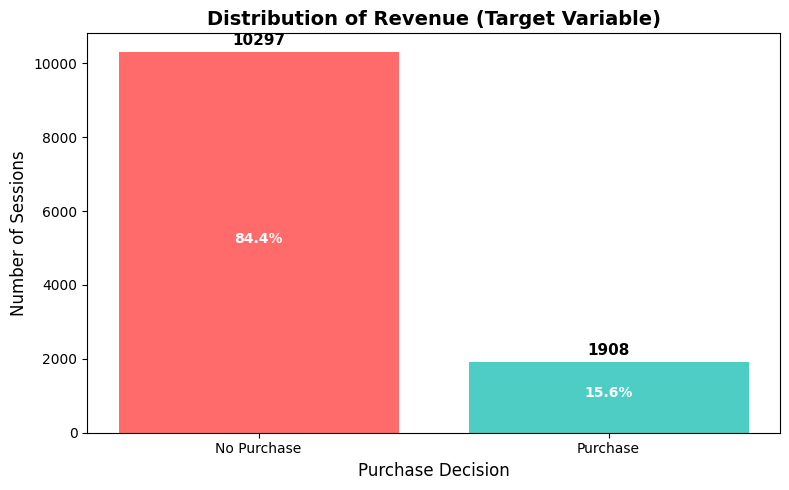

In [75]:
# visualize target variable distribution
plt.figure(figsize=(8, 5))
revenue_counts = df_clean['Revenue'].value_counts()
plt.bar(['No Purchase', 'Purchase'], revenue_counts.values, color=['#FF6B6B', '#4ECDC4'])
plt.title('Distribution of Revenue (Target Variable)', fontsize=14, fontweight='bold')
plt.ylabel('Number of Sessions', fontsize=12)
plt.xlabel('Purchase Decision', fontsize=12)

# add value labels on bars
for i, v in enumerate(revenue_counts.values):
    plt.text(i, v + 200, str(v), ha='center', fontsize=11, fontweight='bold')
    percentage = (v / len(df_clean)) * 100
    plt.text(i, v/2, f'{percentage:.1f}%', ha='center', fontsize=10, color='white', fontweight='bold')

plt.tight_layout()
plt.show()


The target variable shows significant class imbalance with 84.4% non-purchase sessions and 15.6% purchase sessions. This imbalance is typical in e-commerce where most visitors browse without buying. This will be important to address during modeling, potentially using techniques like SMOTE or class weighting.


**2.1.2 Administrative Pages**


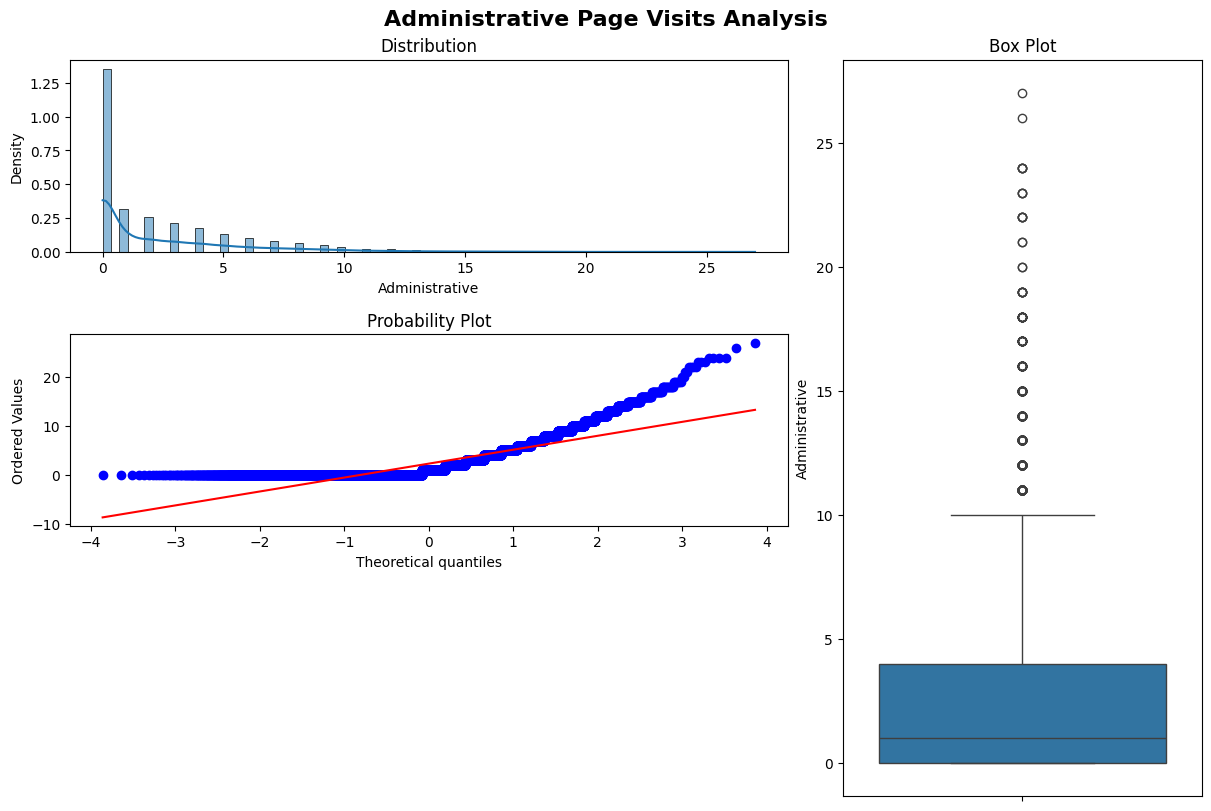

In [76]:
plotting_3_chart(df, 'Administrative', plot_title='Administrative Page Visits Analysis')

**Findings**

**_Distribution Plot (Histogram)_**

- **Observations**:
  - The data displays a right-skewed distribution, with the majority of values concentrated at 0
  - The peak of the distribution is at 0, indicating most sessions visit zero administrative pages
  - The density decreases rapidly as the page count increases, suggesting higher visit counts are less frequent
  - Long tail extends to approximately 27 pages
- **Insight**: Most shoppers completely skip administrative pages, going straight to browsing products. Only a small subset explores multiple admin pages, potentially indicating users with account issues, complex inquiries, or non-purchase intent.

---

**_Probability Plot (QQ Plot)_**

- **Observations**:
  - The points deviate significantly from the red diagonal line (theoretical quantiles of a normal distribution), particularly at the upper end
  - The pronounced deviation at the upper tail underscores that the data has a longer tail than a normal distribution, aligning with the right-skewness observed in the histogram
  - Lower tail shows slight deviation below the line
- **Insight**: The "Administrative" column does not adhere to a normal distribution. Its skewness suggests that transformations (e.g., log or square root) may be necessary if normality is a prerequisite for subsequent analyses or modeling.

---

**_Box Plot_**

- **Observations**:
  - The box is heavily skewed toward the lower end, with the median at 1, further emphasizing the right-skewness of the data
  - Numerous outliers (dots beyond the whiskers) are evident from 10 to 27, representing sessions with unusually high admin page visits
  - The interquartile range (IQR) spans from 0 to 4, indicating that the majority of page values fall within a narrow range of low values
- **Insight**: The presence of outliers highlights that certain users engage heavily with administrative pages, which is atypical behavior. These outliers warrant further investigation to understand if they represent legitimate power users, customers with problems, or potentially automated bot activity.


**2.1.3 Administrative Duration**


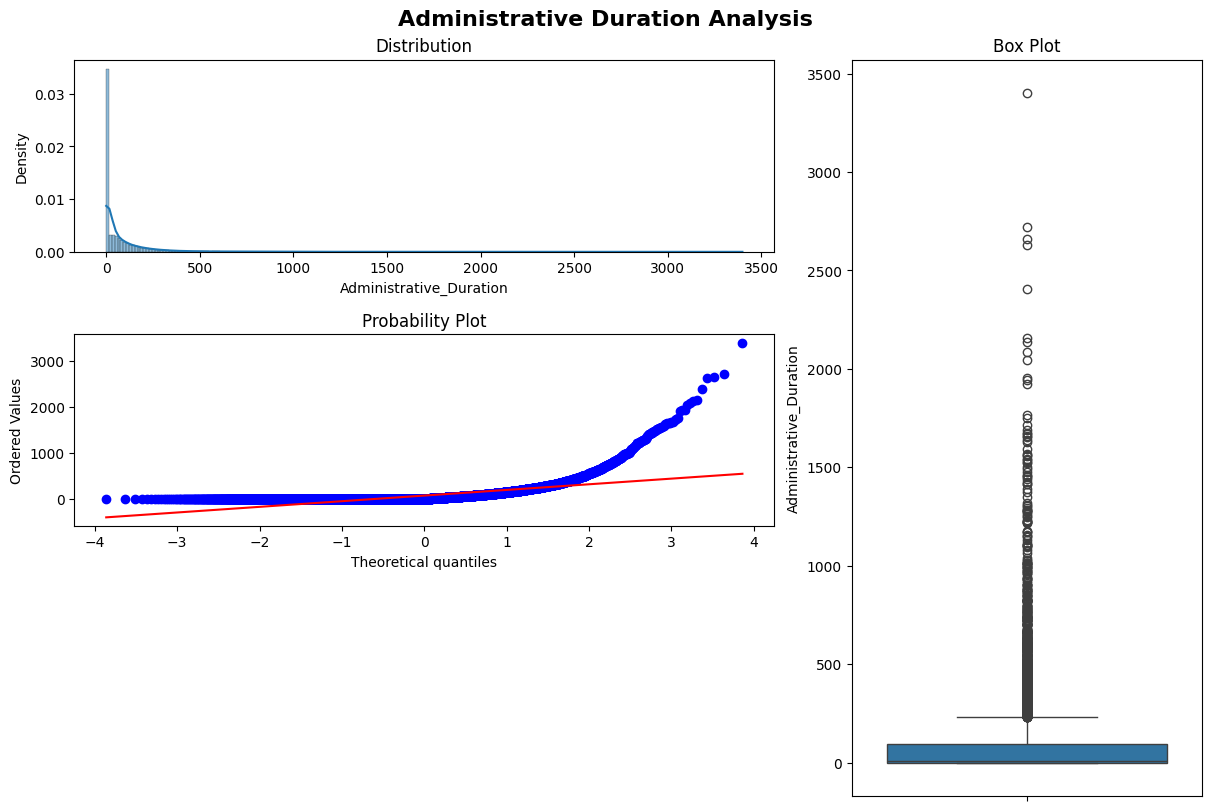

In [77]:
plotting_3_chart(df, 'Administrative_Duration', plot_title='Administrative Duration Analysis')

**Findings**

**_Distribution Plot (Histogram)_**

- **Observations**:
  - The data displays an extremely right-skewed distribution, with density peaking sharply at 0 (density ~0.035)
  - The peak occurs near 0, indicating the vast majority of sessions spend minimal or zero time on administrative pages
  - Density drops precipitously from 0-500 seconds and approaches zero beyond 500 seconds
  - Long tail extends to approximately 3500 seconds with negligible density
- **Insight**: Most users either skip administrative pages entirely or spend only brief moments (<1 minute) on them. The few users spending extended time (10+ minutes) likely indicate engagement with complex account issues, extensive profile updates, or troubleshooting scenarios rather than typical shopping behavior.

---

**_Probability Plot (QQ Plot)_**

- **Observations**:
  - Points closely follow the red diagonal line from -4 to +1 theoretical quantiles
  - Severe upward deviation begins at quantile +2, with points curving sharply above the line
  - The pronounced deviation at the upper tail indicates the data has a much longer right tail than a normal distribution
  - Lower tail (left side) shows minimal deviation, staying close to the line
- **Insight**: The "Administrative_Duration" column does not adhere to a normal distribution. The extreme right-skewness suggests that log transformation is strongly recommended for normalization if this feature is used in models assuming normality (e.g., linear regression, parametric tests).

---

**_Box Plot_**

- **Observations**:
  - The box is compressed at the bottom with median at approximately 0, emphasizing extreme right-skewness
  - The interquartile range (IQR) spans from 0 to approximately 50-100 seconds, indicating 50% of users spend very little time on admin pages
  - Upper whisker extends to approximately 200-250 seconds
  - Massive number of outliers densely clustered from 250 to 3500 seconds, representing sessions with unusually long administrative duration
- **Insight**: The extreme compression of the box and the dense cloud of outliers highlight that typical user behavior involves minimal administrative page engagement, while a distinct subset of users spend disproportionately long periods. These outliers may represent customers resolving account issues, reading extensive policies, or potentially abandoned sessions left open on admin pages.


**2.1.4 Informational Pages**


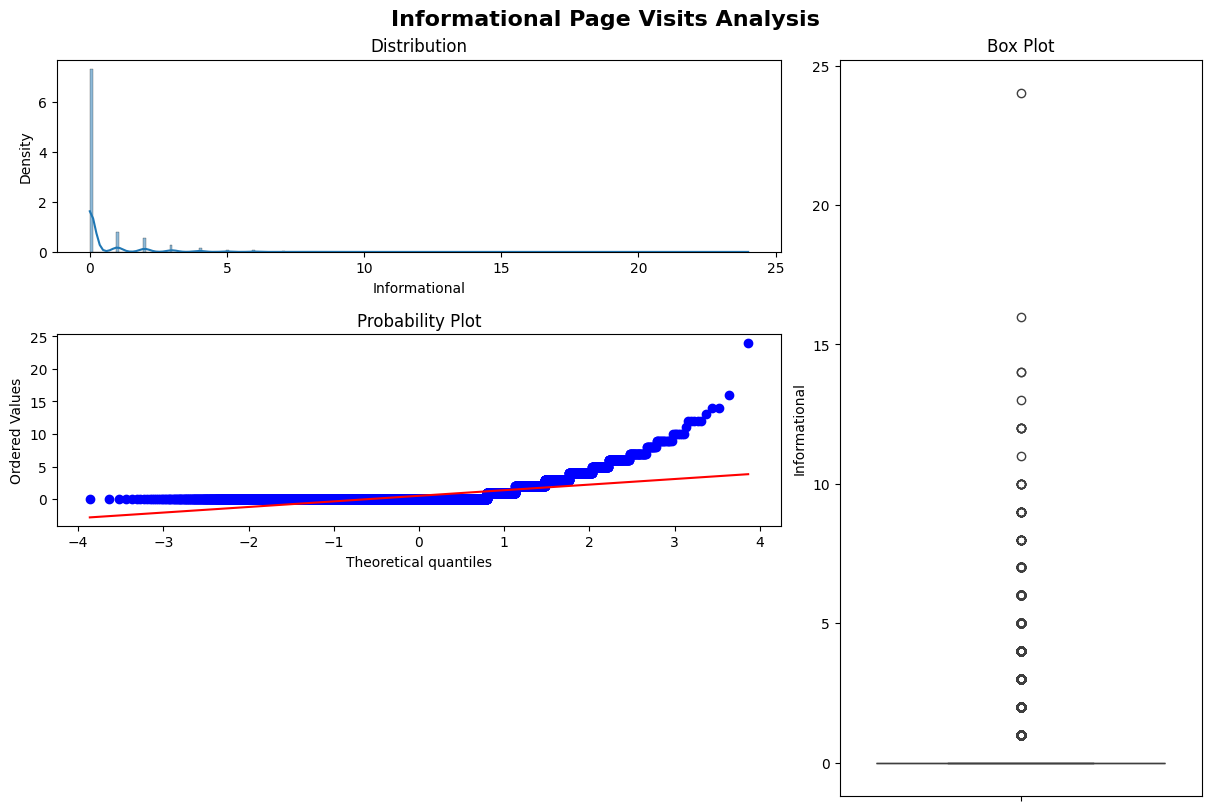

In [78]:
plotting_3_chart(df, 'Informational', plot_title='Informational Page Visits Analysis')

**Findings**

**_Distribution Plot (Histogram)_**

- **Observations**:
  - The data displays an extremely right-skewed distribution, with density peaking dramatically at 0 (density ~7)
  - The peak occurs at 0, indicating the vast majority of sessions visit zero informational pages
  - Density decreases sharply from 0 to 5, with minimal density beyond 5 pages
  - Long tail extends to approximately 24 pages with negligible density throughout
- **Insight**: Most shoppers completely bypass informational pages (About Us, FAQ, Shipping Info, Reviews), focusing directly on product browsing. Only a tiny fraction explores multiple informational pages, potentially indicating research-oriented shoppers, first-time visitors seeking site information, or users comparing policies before purchase.

---

**_Probability Plot (QQ Plot)_**

- **Observations**:
  - Points closely follow the red diagonal line from -4 to approximately 0 theoretical quantiles
  - Significant upward deviation begins at quantile +1, with points curving progressively above the line
  - The pronounced deviation at the upper tail indicates the data has a substantially longer right tail than a normal distribution
  - Lower tail shows minimal deviation, remaining close to the theoretical line
- **Insight**: The "Informational" column does not adhere to a normal distribution. The severe right-skewness suggests that transformations (e.g., log or square root) are necessary if normality is required for subsequent statistical analyses or models assuming normal distribution.

---

**_Box Plot_**

- **Observations**:
  - The box is extremely compressed at the bottom with median at 0, emphasizing extreme right-skewness
  - The interquartile range (IQR) spans from 0 to approximately 0, indicating that at least 75% of users visit zero informational pages
  - Upper whisker extends to approximately 0 (box nearly invisible)
  - Multiple outliers scattered from 1 to 24, representing sessions with any informational page visits at all
- **Insight**: The nearly invisible box reveals that informational page engagement is exceptionally rare in typical shopping sessions. Users visiting even 1-2 informational pages are statistical outliers. This suggests informational pages may be weak predictors for most users, but their presence could signal specific user types (researchers, cautious buyers, comparison shoppers) worth segmenting separately.


**2.1.5 Informational_Duration**


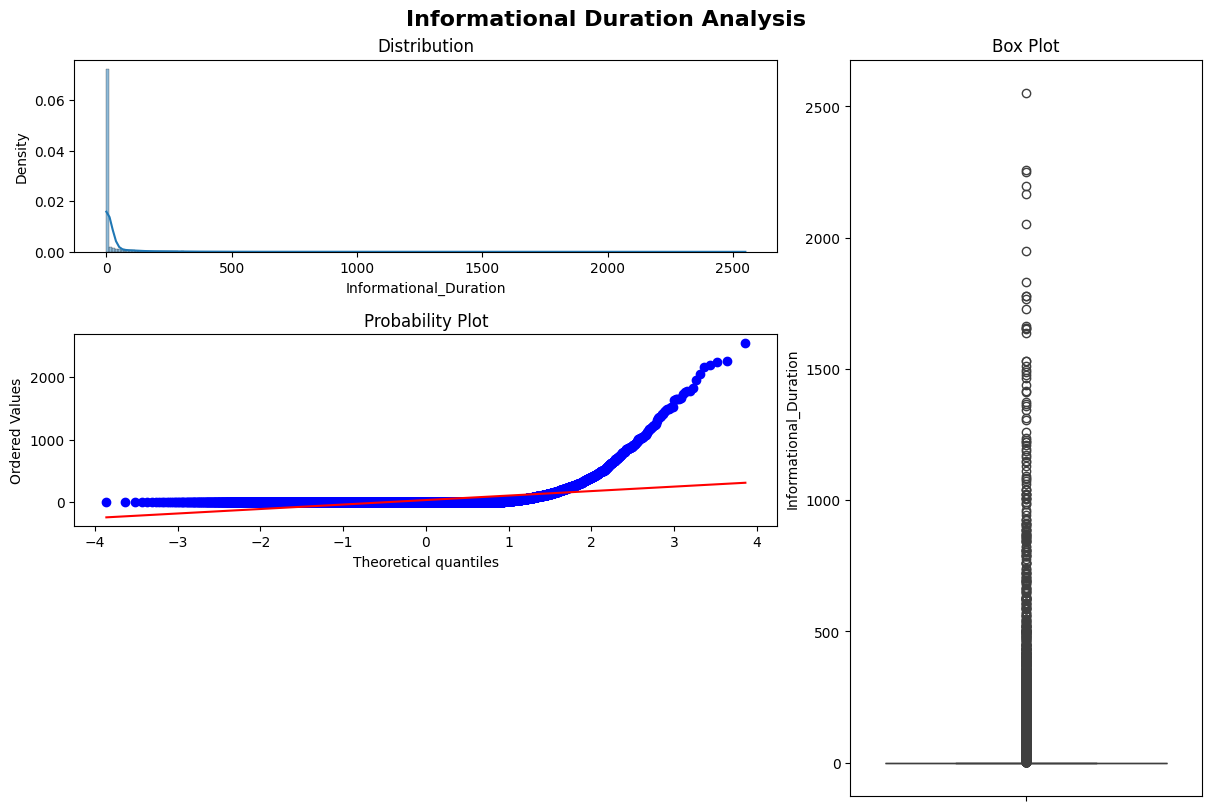

In [79]:
plotting_3_chart(df, 'Informational_Duration', plot_title='Informational Duration Analysis')

**Findings**

**_Distribution Plot (Histogram)_**

- **Observations**:
  - The data displays an extremely right-skewed distribution, with density peaking sharply at 0 (density ~0.07)
  - The peak occurs near 0, indicating the vast majority of sessions spend zero or minimal time on informational pages
  - Density drops precipitously from 0-500 seconds and approaches zero beyond 500 seconds
  - Long tail extends to approximately 2500 seconds with negligible density
- **Insight**: Most users either completely skip informational pages or spend only seconds on them, suggesting they enter the site with clear purchase intent or prior knowledge. The few users spending extended time (5+ minutes) likely represent first-time buyers conducting due diligence on policies, cautious shoppers researching legitimacy, or users comparing detailed product information before committing to purchase.

---

**_Probability Plot (QQ Plot)_**

- **Observations**:
  - Points closely follow the red diagonal line from -4 to approximately +1 theoretical quantiles
  - Significant upward deviation begins at quantile +2, with points curving sharply above the line
  - The pronounced deviation at the upper tail indicates the data has a much longer right tail than a normal distribution
  - Lower tail shows minimal deviation, staying close to the theoretical line
- **Insight**: The "Informational_Duration" column does not adhere to a normal distribution. The extreme right-skewness suggests that log transformation is strongly recommended for normalization if this feature is used in models assuming normality (e.g., linear regression).

---

**_Box Plot_**

- **Observations**:
  - The box is compressed at the bottom with median at 0, emphasizing extreme right-skewness
  - The interquartile range (IQR) spans from 0 to approximately 0, indicating at least 75% of users spend zero time on informational pages
  - Upper whisker extends to approximately 0 (box nearly invisible)
  - Dense cluster of outliers from approximately 500 to 2500 seconds, representing sessions with any substantial informational page engagement
- **Insight**: The nearly collapsed box reveals that informational page engagement is virtually absent in typical shopping behavior. Any time spent on informational pages (even 30 seconds) constitutes outlier behavior. This pattern suggests informational duration may have limited predictive power for the general population but could be a strong signal for segmenting deliberate, research-oriented shoppers from impulse or returning buyers.


**2.1.6 Product-Related Features**

These features track user interaction with product pages, which are likely strong predictors of purchase behavior.


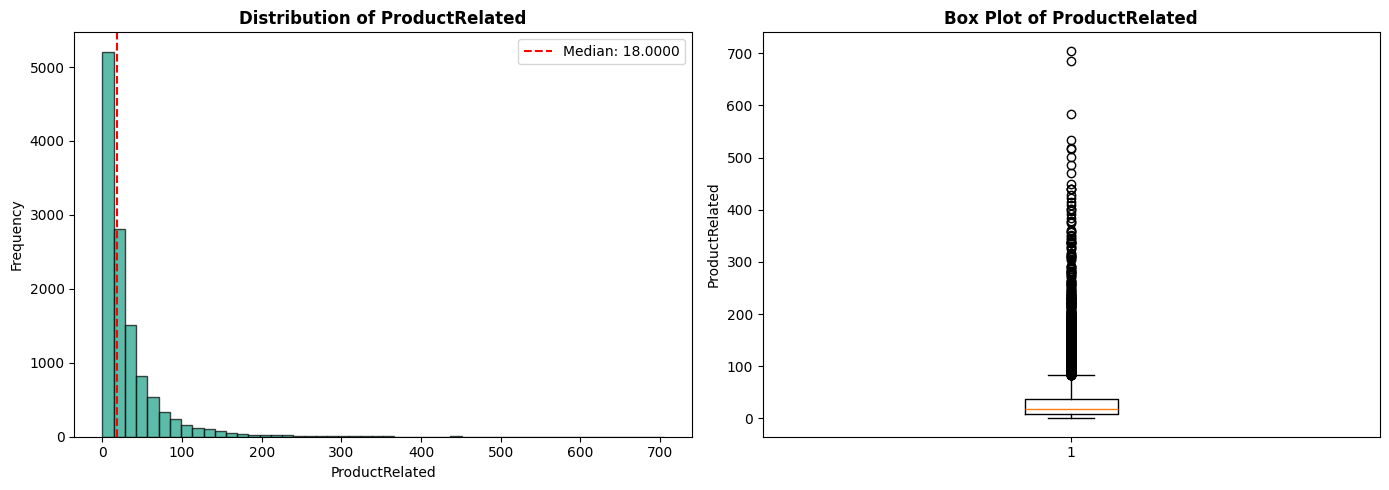

Mean: 32.0456
Median: 18.0000


In [80]:
# distribution of ProductRelated pages visited
plotting_2_chart(df_clean, 'ProductRelated')


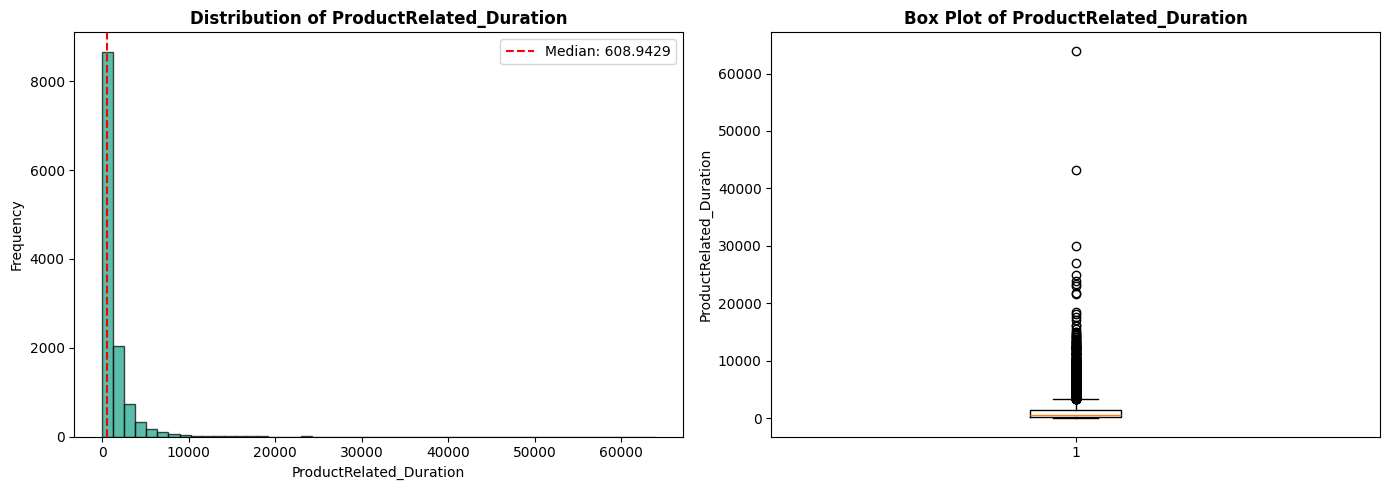

Mean: 1206.9825
Median: 608.9429
Std: 44.59


In [81]:
# distribution of ProductRelated_Duration
plotting_2_chart(df_clean, 'ProductRelated_Duration')
print(f"Std: {df_clean['ProductRelated'].std():.2f}")


The ProductRelated features show right-skewed distributions. Most users visit around 18 product pages (median) with a mean of 31.7 pages, indicating some users browse extensively. The duration also shows high variability with a median of 609 seconds (about 10 minutes). The presence of many outliers in the boxplot suggests diverse browsing behaviors, which may be useful for clustering analysis.


**2.1.8 BounceRates (Engagement Metric)**

BounceRate indicates the percentage of visitors who leave immediately. Lower bounce rates typically suggest better engagement.


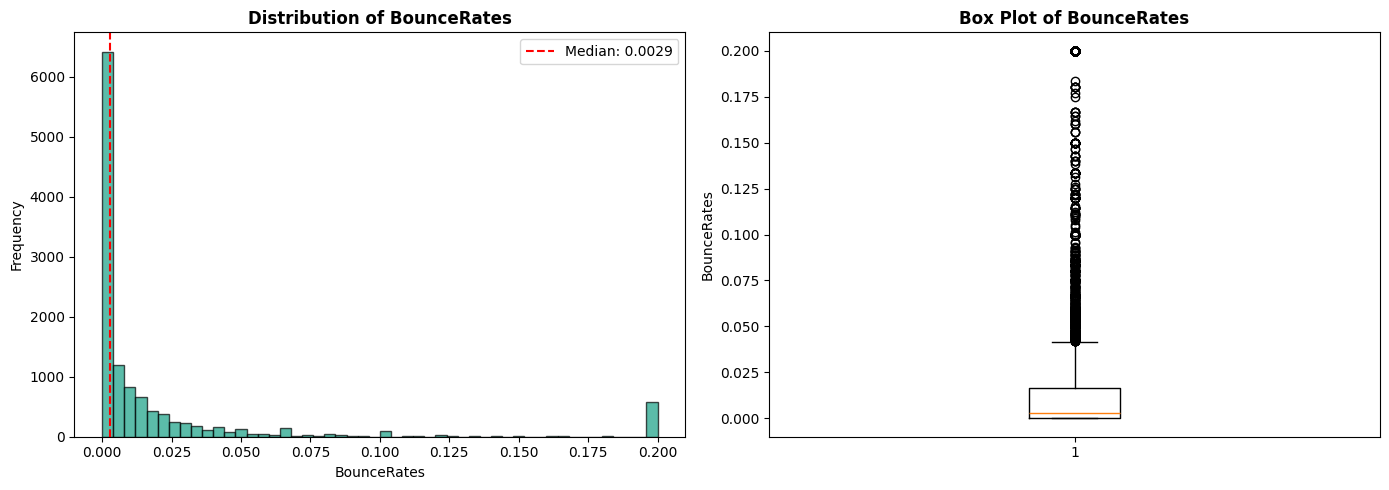

Mean: 0.0204
Median: 0.0029


In [82]:
# distribution of BounceRates
plotting_2_chart(df_clean, 'BounceRates')

BounceRates show that most sessions have very low bounce rates (median 0.0029), indicating users generally engage with multiple pages. The presence of outliers at higher bounce rates suggests some sessions with poor engagement.


**2.1.9 ExitRates (Session Ending Metric)**

ExitRate measures the percentage of pageviews that were the last in the session. This helps identify pages where users leave the site.


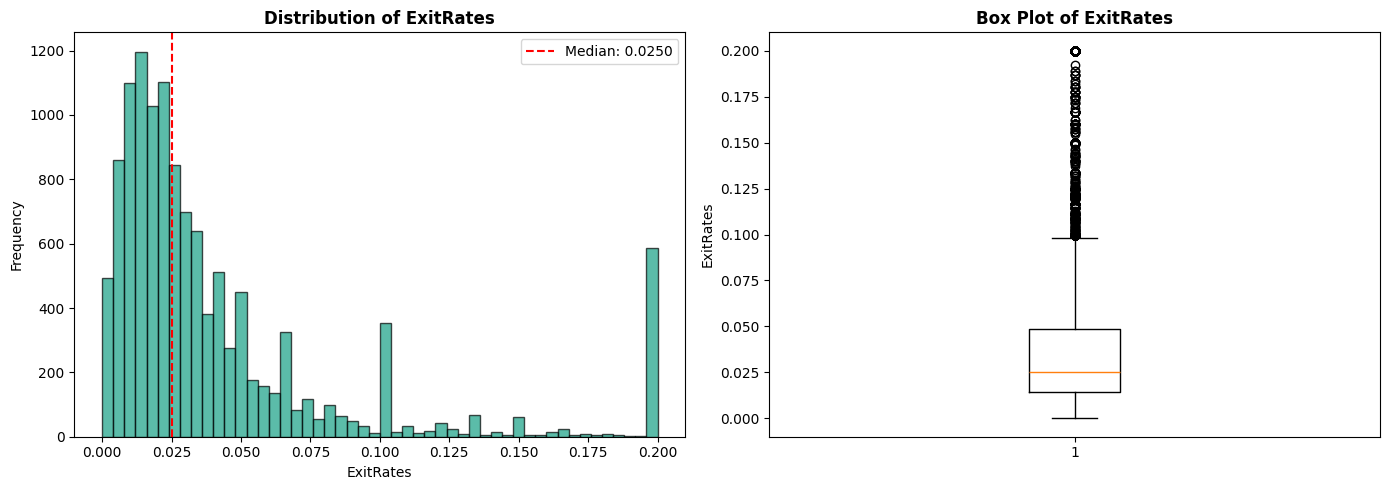

Mean: 0.0415
Median: 0.0250


In [83]:
# distribution of ExitRates
plotting_2_chart(df_clean, 'ExitRates')


ExitRates have a median of 0.025 with more spread than BounceRates. The distribution shows that exit behavior varies significantly across sessions, which may help differentiate between purchasers and non-purchasers.


**2.1.10 PageValues (Transaction Value Indicator)**

PageValues represents the average value of pages visited before a transaction. This is a critical feature as it directly relates to purchase intent.


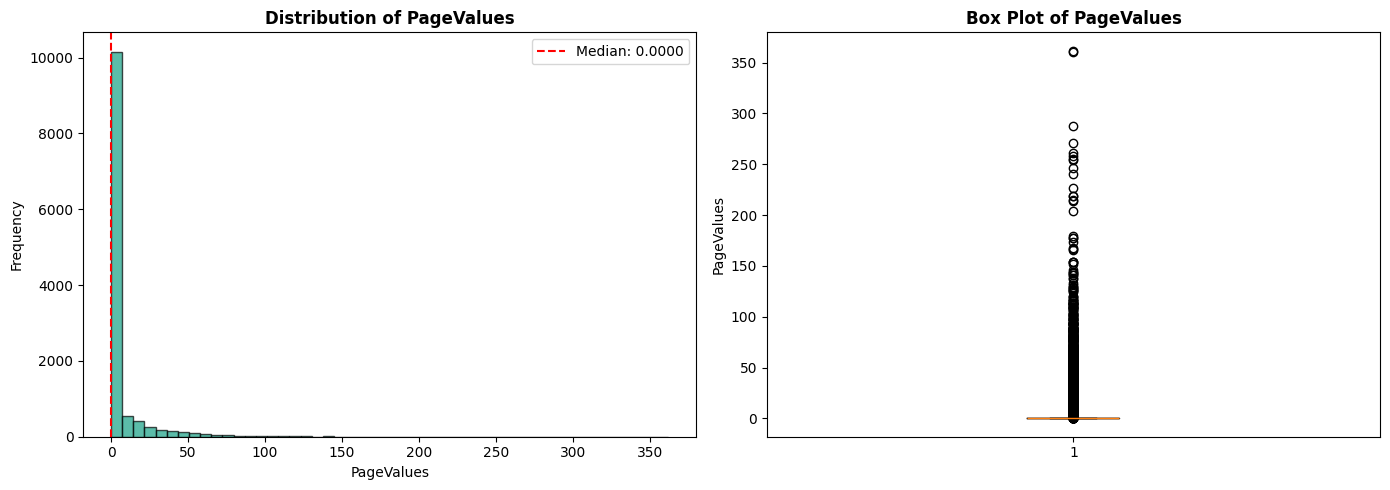

Mean: 5.9496
Median: 0.0000
Non-zero PageValues: 2730 (22.4%)


In [84]:
# distribution of PageValues
plotting_2_chart(df_clean, 'PageValues')
print(f"Non-zero PageValues: {(df_clean['PageValues'] > 0).sum()} ({(df_clean['PageValues'] > 0).sum() / len(df_clean) * 100:.1f}%)")


PageValues is highly skewed with median of 0, meaning 77.6% of sessions have zero page value (no purchase intent tracked). Only 22.4% of sessions show non-zero values, which aligns with our purchase rate. This feature will be a strong predictor for classification.


**2.1.11 SpecialDay**


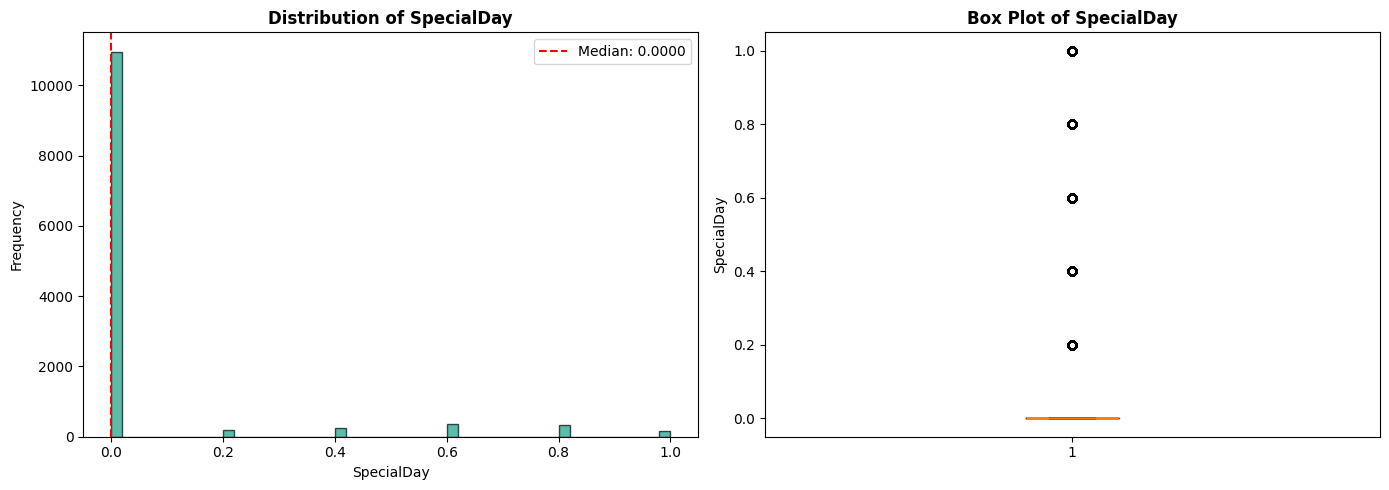

Mean: 0.0619
Median: 0.0000


In [93]:
plotting_2_chart(df_clean, 'SpecialDay')

**Findings**

**_Distribution Plot (Histogram)_**

- **Observations**:
    - The distribution is extremely zero-inflated, with a massive bar located at 0.0 (frequency > 10,000).
    - The remaining values appear at discrete intervals (0.2,0.4,0.6,0.8,1.0) with very low frequencies compared to the zero bucket.
    - The red dashed line indicates the Median is 0.0000, confirming that at least 50% of the data points have a value of zero.
- **Insight**: The vast majority of shopping sessions (>90%) occur on regular days with no proximity to special occasions like Valentine's Day or Mother's Day. The small clusters at 0.2, 0.4, 0.6, 0.8, and 1.0 represent sessions occurring at specific distances from these special days, following the dataset's proximity scoring system. This suggests that special day proximity is a rare event but may have strong predictive power when present, as retailers often see behavioral changes during holiday shopping windows.

---

**_Box Plot_**

- **Observations**:
  - The box body is completely collapsed into a single line at 0, implying that the 25th percentile, Median, and 75th percentile are all likely zero.
  - There are distinct, symmetrical outliers plotted at regular intervals (0.2,0.4,0.6,0.8,1.0).
  - No whiskers are visible, suggesting the non-outlier range is entirely contained within the value 0.
- **Insight**: The collapsed box confirms that typical shopping behavior occurs on non-special days. Any session with SpecialDay > 0 is statistically an outlier, representing less than 10% of all traffic. However, these "outliers" are actually meaningful business events - they represent strategic shopping windows around holidays. For modeling purposes, SpecialDay may be more effective as a binary feature (special vs. non-special day) or categorical bins rather than treating it as a continuous variable, given its discrete nature and extreme imbalance.


**2.1.12 Month (Seasonal Patterns)**

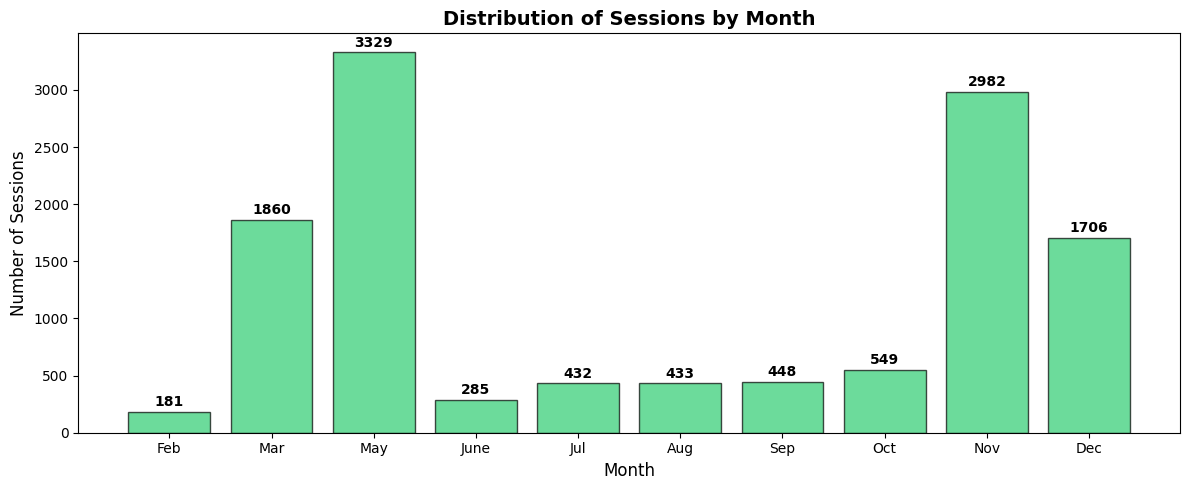


Session counts by month:
Month
Feb      181
Mar     1860
May     3329
June     285
Jul      432
Aug      433
Sep      448
Oct      549
Nov     2982
Dec     1706
Name: count, dtype: int64


In [86]:
# distribution of sessions by month
month_order = ['Feb', 'Mar', 'May', 'June', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
month_counts = df_clean['Month'].value_counts().reindex(month_order)

plt.figure(figsize=(12, 5))
plt.bar(month_counts.index, month_counts.values, color='#2ecc71', edgecolor='black', alpha=0.7)
plt.title('Distribution of Sessions by Month', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Sessions', fontsize=12)

# add value labels on bars
for i, v in enumerate(month_counts.values):
    plt.text(i, v + 50, str(v), ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nSession counts by month:")
print(month_counts)


Sessions are heavily concentrated in May (3,329 sessions) and November (2,982 sessions), likely corresponding to major shopping events. March and December also show high activity. This seasonal pattern suggests shopping behavior varies by month and could be useful for both classification and clustering.


**2.1.13 OperatingSystems - Bar plots**


In [87]:
# Visualization code to be added

**Findings**

[To be completed]


**2.1.14 Browser - Bar plots**


In [88]:
# Visualization code to be added

**Findings**

[To be completed]


**2.1.15 Region - Bar plots**


In [89]:
# Visualization code to be added

**Findings**

[To be completed]


**2.1.16 TrafficType - Bar plots**


In [90]:
# Visualization code to be added

**Findings**

[To be completed]


**2.1.17 VisitorType (User Segmentation)**

VisitorType categorizes users as returning visitors, new visitors, or other. This may influence purchase behavior.


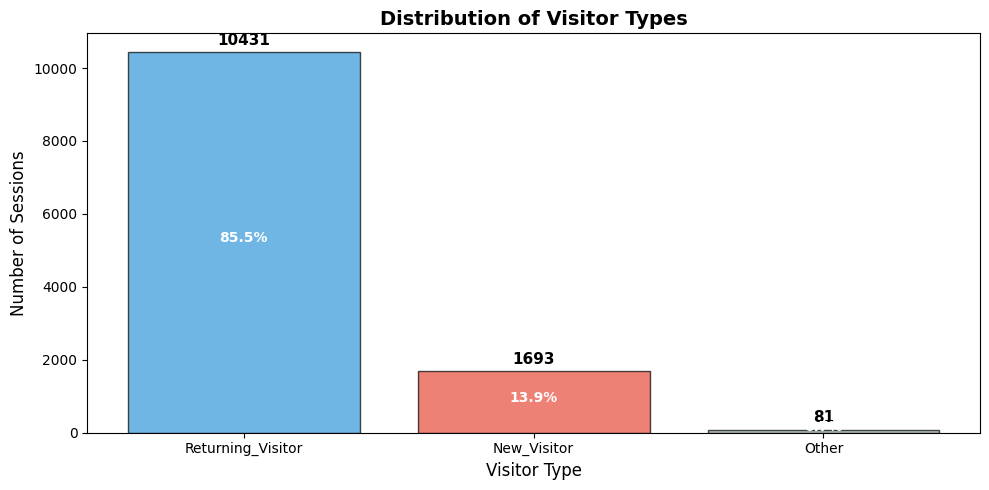

Visitor type distribution:
VisitorType
Returning_Visitor    10431
New_Visitor           1693
Other                   81
Name: count, dtype: int64

Percentages:
VisitorType
Returning_Visitor    85.464973
New_Visitor          13.871364
Other                 0.663662
Name: count, dtype: float64


In [91]:
# distribution of VisitorType
visitor_counts = df_clean['VisitorType'].value_counts()

plt.figure(figsize=(10, 5))
plt.bar(visitor_counts.index, visitor_counts.values, color=['#3498db', '#e74c3c', '#95a5a6'], 
        edgecolor='black', alpha=0.7)
plt.title('Distribution of Visitor Types', fontsize=14, fontweight='bold')
plt.xlabel('Visitor Type', fontsize=12)
plt.ylabel('Number of Sessions', fontsize=12)

# add value labels on bars
for i, v in enumerate(visitor_counts.values):
    plt.text(i, v + 200, str(v), ha='center', fontsize=11, fontweight='bold')
    percentage = (v / len(df_clean)) * 100
    plt.text(i, v/2, f'{percentage:.1f}%', ha='center', fontsize=10, color='white', fontweight='bold')

plt.tight_layout()
plt.show()

print("Visitor type distribution:")
print(visitor_counts)
print(f"\nPercentages:")
print(visitor_counts / len(df_clean) * 100)


The majority of sessions are from returning visitors (85.5%), with only 13.9% from new visitors. This suggests the website has a strong repeat visitor base. The "Other" category is minimal (0.7%). This imbalance may influence purchase patterns and will be important for clustering analysis.


**2.1.18 Weekend (Temporal Pattern)**

Understanding whether sessions occur on weekends versus weekdays may reveal different shopping behaviors.


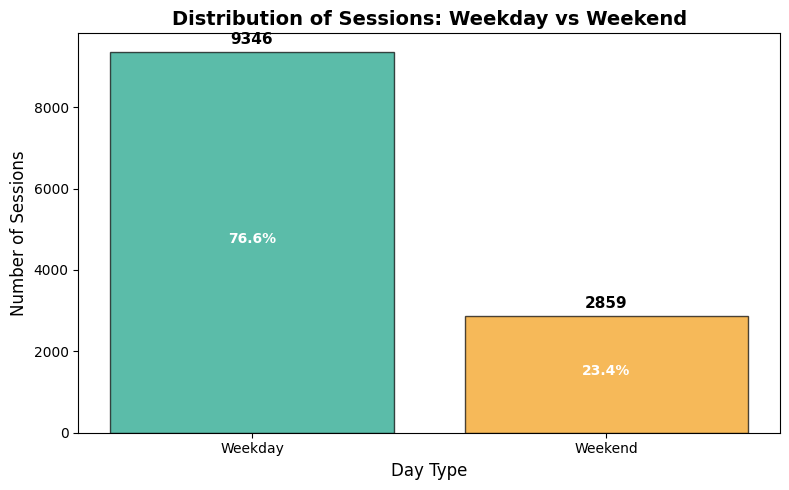

Weekend distribution:
Weekend
False    9346
True     2859
Name: count, dtype: int64

Percentages:
Weekend
False    76.575174
True     23.424826
Name: count, dtype: float64


In [92]:
# distribution of Weekend sessions
weekend_counts = df_clean['Weekend'].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(['Weekday', 'Weekend'], weekend_counts.values, color=['#16a085', '#f39c12'], 
        edgecolor='black', alpha=0.7)
plt.title('Distribution of Sessions: Weekday vs Weekend', fontsize=14, fontweight='bold')
plt.xlabel('Day Type', fontsize=12)
plt.ylabel('Number of Sessions', fontsize=12)

# add value labels on bars
for i, v in enumerate(weekend_counts.values):
    plt.text(i, v + 200, str(v), ha='center', fontsize=11, fontweight='bold')
    percentage = (v / len(df_clean)) * 100
    plt.text(i, v/2, f'{percentage:.1f}%', ha='center', fontsize=10, color='white', fontweight='bold')

plt.tight_layout()
plt.show()

print("Weekend distribution:")
print(weekend_counts)
print(f"\nPercentages:")
print(weekend_counts / len(df_clean) * 100)


Most sessions occur on weekdays (76.6%) compared to weekends (23.4%). This is expected for online shopping, though weekend sessions might show different purchasing behaviors worth investigating in bivariate analysis.


### 2.2 Bivariate Analysis

**2.2.1 Correlation Matrix**

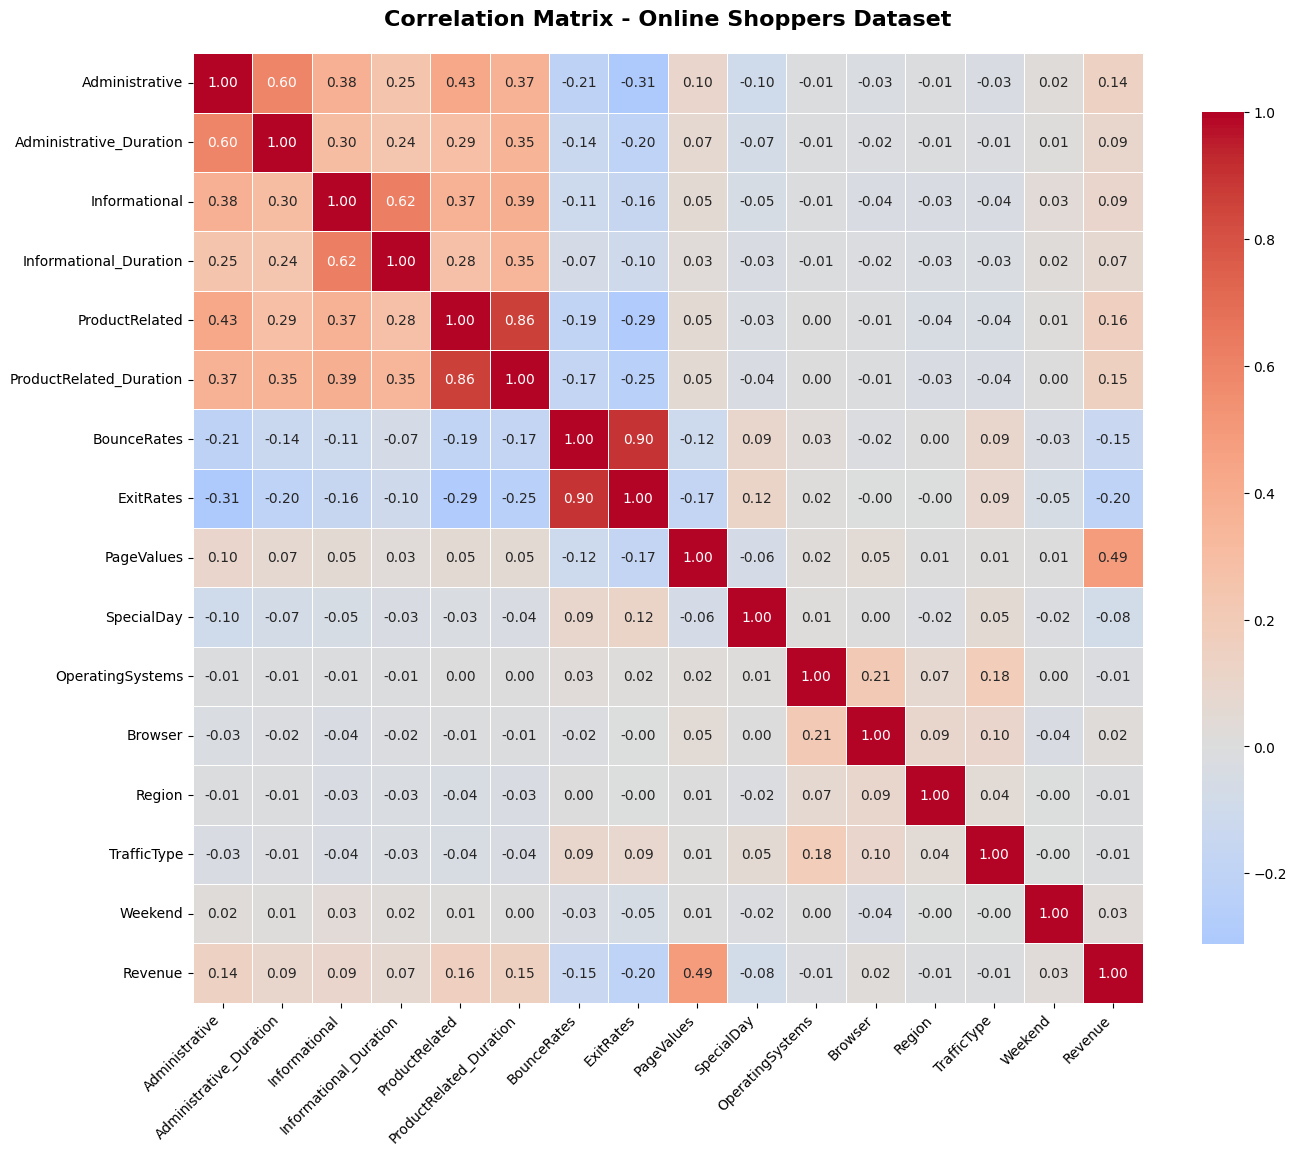

In [98]:
plt.figure(figsize=(14, 12))
corr_matrix = df_clean.corr(numeric_only=True)
sns.heatmap(corr_matrix, 
            annot=True,  # Show correlation values
            fmt='.2f',   # 2 decimal places
            cmap='coolwarm',  # Red (positive) to Blue (negative)
            center=0,    # Center colormap at 0
            square=True, # Square cells
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})

plt.title('Correlation Matrix - Online Shoppers Dataset', 
          fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Correlation Matrix – Observation & Insight**

***Strong Feature Redundancy (Multicollinearity)***

**Observation**
- Very strong correlations exist between:
  - `ProductRelated` and `ProductRelated_Duration` (**r ≈ 0.86**)
  - `BounceRates` and `ExitRates` (**r ≈ 0.90**)
  - `Informational` and `Informational_Duration` (**r ≈ 0.62**)
  - `Administrative` and `Administrative_Duration` (**r ≈ 0.60**)

**Insight**
- These feature pairs capture the same underlying user behavior (count vs time).
- Including both features may introduce multicollinearity, leading to unstable coefficients in linear models.
- For interpretable models, one feature per pair should be selected or combined.

---

***Behavioral Signals Linked to Purchase (Revenue)***

**Observation**
- `PageValues` shows the strongest positive correlation with `Revenue` (**r ≈ 0.49**).
- `ProductRelated` and `ProductRelated_Duration` show weak-to-moderate positive correlations with `Revenue` (**r ≈ 0.15–0.16**).
- `BounceRates` and `ExitRates` are negatively correlated with `Revenue` (**r ≈ −0.15 to −0.20**).

**Insight**
- Sessions with higher engagement on product pages are more likely to convert.
- High bounce and exit rates indicate low purchase intent.
- `PageValues` is a strong predictor but may introduce data leakage and should be carefully validated before modeling.

---

***Limited Impact of Technical and Contextual Features***

**Observation**
- `OperatingSystems`, `Browser`, `Region`, `TrafficType`, and `Weekend` show near-zero correlation with `Revenue`.

**Insight**
- Technical and contextual attributes have minimal direct influence on purchasing behavior.
- User intent is driven more by on-site behavior than by device or traffic source.
- These features may still contribute through nonlinear interactions but are weak standalone predictors.

---

***Modeling Implication (Summary)***

- The dataset is dominated by behavioral engagement signals rather than demographic or technical factors.
- Feature selection should:
  - Address multicollinearity
  - Prioritize engagement-based variables
  - Carefully assess `PageValues` for potential leakage
- Tree-based or regularized models are well-suited to this feature structure.